№ 1
(2 балла)
Предположим, что вы собираетесь в турпоход. У вас есть рюкзак, емкость которого
составляет 6 фунтов, и список предметов, которые вы можете положить с собой в рюкзак.
У каждого предмета есть вес и ценность. Чем выше ценность, тем важнее для вас предмет.
Нарисуйте и вручную заполните таблицу, которая даст оптимальный набор предметов для
похода и общую ценность получившегося рюкзака. Ориентируйтесь на алгоритм
динамического программирования, описанный в лекции.
Список предметов возьмите согласно вашему варианту.

Вариант 1.
1. вода, 3 фунта, 5;
2. книга, 1 фунт, 3;
3. еда, 2 фунта, 6;
4. куртка, 2 фунта, 5;
5. камера, 1 фунт, 6 

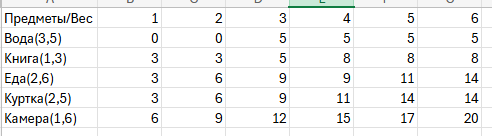

Сумка 6 фунтов: [камера(1 фунт, 6), куртка(2 фунта, 5), еда(2 фунта, 6), книга(1 фунт, 3)] итого 6+6+5+3 = 20 ценности

№ 3
(2 балла)
Нарисуйте и вручную заполните таблицу для вычисления самой длинной общей подстроки
между строками blue и clue. Ориентируйтесь на алгоритм динамического
программирования, описанный в лекции.

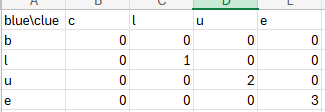

№ 4
(3 балла)
Напишите программу, реализующую алгоритм нахождения самой длинной общей
подстроки из лекции. Пользователь вводит слово с ошибкой и далее список похожих слов.
Ваша программа должна вывести самое похожее слово согласно данному алгоритму.

In [24]:
def common_part(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    max_len = 0
    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
                if dp[i][j] > max_len:
                    max_len = dp[i][j]
    return max_len

miss_word = input("Слово: ")
words = input("Список слов: ").split()

closest = None
best_length = -1

for word in words:
    lcs_len = common_part(miss_word, word)
    if lcs_len > best_length:
        best_length = lcs_len
        closest = word

print(closest)


Лаборатная


№ 5
(3 балла)
Напишите программу, реализующую алгоритм нахождения самой длинной общей подпоследовательности из лекции. Пользователь вводит слово с ошибкой и далее список похожих слов. Ваша программа должна вывести самое похожее слово согласно данному алгоритму.

In [23]:
def common_length(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    return dp[m][n]


miss_word = input("Слово: ")
words = input("Список слов: ").split()

closest = None
best_length = -1

for word in words:
    length = common_length(miss_word, word)
    if length > best_length:
        best_length = length
        closest = word

print(closest)

Лаборатная


№ 6
(4 балла) Имеется n предметов различных размеров (от 0.1 до 1.0). Есть неограниченное количество одинаковых ящиков вместимостью 1.0. Необходимо разложить все n предметов в минимальное количество ящиков.
Напишите программу, реализующую 4 жадных стратегии раскладки предметов по ящикам:
1. Первый подходящий ящик. 2. Наиболее подходящий ящик. 3. Следующий подходящий ящик. 4. Наименее подходящий ящик.

In [17]:
def first_fit(items):
    bins = []
    for item in items:
        placed = False
        for i in range(len(bins)):
            if bins[i] + item <= 1.0:
                bins[i] += item
                placed = True
                break
        if not placed:
            bins.append(item)
    return len(bins)


def best_fit(items):
    bins = []
    for item in items:
        best_index = -1
        min_remainder = float('inf')
        for i in range(len(bins)):
            if bins[i] + item <= 1.0:
                remainder = 1.0 - (bins[i] + item)
                if remainder < min_remainder:
                    min_remainder = remainder
                    best_index = i
        if best_index != -1:
            bins[best_index] += item
        else:
            bins.append(item)
    return len(bins)


def next_fit(items):
    if not items:
        return 0
    bins = [items[0]]
    current = 0 
    for item in items[1:]:
        if bins[current] + item <= 1.0:
            bins[current] += item
        else:
            bins.append(item)
            current += 1
    return len(bins)


def worst_fit(items):
    bins = []
    for item in items:
        worst_index = -1
        max_remainder = -1
        for i in range(len(bins)):
            if bins[i] + item <= 1.0:
                remainder = 1.0 - (bins[i] + item)
                if remainder > max_remainder:
                    max_remainder = remainder
                    worst_index = i
        if worst_index != -1:
            bins[worst_index] += item
        else:
            bins.append(item)
    return len(bins)

items = [0.5, 0.7, 0.3, 0.9, 0.6, 0.8, 0.1, 0.4, 0.2, 0.5]

print("Первый подходящий",first_fit(items))
print("Наиболее подходящий", best_fit(items))
print("Следующий подходящий", next_fit(items))
print("Наименее подходящий", worst_fit(items))

Первый подходящий 6
Наиболее подходящий 5
Следующий подходящий 7
Наименее подходящий 7


№ 7
(4 балла) Есть купюры и монеты номиналами: 1, 3, 4, 10, 50, 100. В банкомате неограниченное количество купюр и монет каждого номинала. Мы хотим снять со счета n рублей. Нужно вывести на экран минимальный набор купюр и монет, который может выдать банкомат, чтобы сумма получилась ровно n.
1. Напишите жадный алгоритм решения задачи. Подсказка: выбирайте купюры и монеты по убыванию номинала.
2. Используйте динамическое программирование, чтобы рассчитать минимальное количество требуемых купюр и монет.
3. Приведите пример входных данных, когда жадный алгоритм выдает не оптимальное решение.

Жадный алгоритм. Из-за наличия монет 3, 4 выходят неоптимальные решения.

In [18]:
def greedy(n):
    denominations = [100, 50, 10, 4, 3, 1 ]
    result = []
    total_count = 0
    for coin in denominations:
        count = n // coin
        if count > 0:
            result.append((coin, count))
            total_count += count
            n = n - (coin * count)
        if n == 0:
            break
    return total_count, result

greedy(6)

(3, [(4, 1), (1, 2)])

In [19]:
def dp(n):
    denominations = [100, 50, 10, 4, 3, 1]
    dp = [float('inf')] * (n + 1)
    parent = [-1] * (n + 1)
    dp[0] = 0

    for i in range(1, n + 1):
        for coin in denominations:
            if coin <= i and dp[i - coin] + 1 < dp[i]:
                dp[i] = dp[i - coin] + 1
                parent[i] = coin

    if dp[n] == float('inf'):
        return -1, []
    
    count_dict = {}
    current = n
    while current > 0:
        coin = parent[current]
        if coin == -1:
            break
        count_dict[coin] = count_dict.get(coin, 0) + 1
        current -= coin
        
    result = sorted(count_dict.items(), reverse=True)
    return dp[n], result

    

print(dp(6))

(2, [(3, 2)])


№ 8
(4 балла)
Напишите программу, моделирующую работу клиентов с банкоматом. В банкомате есть купюры и монеты номиналами: 1, 3, 4, 10, 50, 100, но, в отличие от предыдущей задачи, их количество конечно.
В начале работы программы вы задаете:
 количество клиентов
 для каждого клиента количество рублей, которые он хочет снять (считаем, что эта сумма всегда корректна и имеется на счету клиента)
 изначальное количество купюр и монет в банкомате
Далее вы по очереди обрабатываете запросы клиентов. Для каждого клиента выведите на экран минимальный набор купюр и монет для его суммы или сообщение о невозможности предоставить данную суммы из-за нехватки купюр и монет. Если минимальный набор найден успешно, то вычтите его из запасов банкомата и выведите на экран получившейся остаток.
Проведите несколько запусков программы с разными начальными данными и различными исходами работы с банкоматом.

In [21]:
def greedy_limited(amount, atm):
    denominations = [100, 50, 10, 4, 3, 1]
    result = {}
    for coin in denominations:
        if amount == 0:
            break

        need = amount // coin
        available = atm.get(coin, 0)
        take = min(need, available)

        if take > 0:
            result[coin] = take
            amount -= coin * take

    if amount != 0:
        return None
    
    return result


def print_atm(atm):
    print("Остаток купюр ")
    for coin in sorted(atm.keys(), reverse=True):
        print(f"{coin}: {atm[coin]}")
    print()

clients_requests = [45, 22, 157, 143]
atm = {100: 2, 50: 5, 10: 6, 4: 7, 3: 8, 1: 16}

print_atm(atm)

for i, amount in enumerate(clients_requests, 1):
    result = greedy_limited(amount, atm)
    if result is None:
        print("Невозможнос предоставить данную сумму из-за нехватки купюр и монет")
        continue

    print("Выдано ")
    for coin, count in result.items():
        print(coin," ",count)

    for coin, count in result.items():
        atm[coin] -= count

    print_atm(atm)


Остаток купюр 
100: 2
50: 5
10: 6
4: 7
3: 8
1: 16

Выдано 
10   4
4   1
1   1
Остаток купюр 
100: 2
50: 5
10: 2
4: 6
3: 8
1: 15

Выдано 
10   2
1   2
Остаток купюр 
100: 2
50: 5
10: 0
4: 6
3: 8
1: 13

Выдано 
100   1
50   1
4   1
3   1
Остаток купюр 
100: 1
50: 4
10: 0
4: 5
3: 7
1: 13

Выдано 
100   1
4   5
3   7
1   2
Остаток купюр 
100: 0
50: 4
10: 0
4: 0
3: 0
1: 11

